importing libraries and loading data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
laptop_prices_df = pd.read_csv('laptop_price - dataset.csv', index_col ='Company', header = 0)
laptop_prices_df.head(8)

,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
Company,,,,,,,,,,,,,,
Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60
Acer,Aspire 3,Notebook,15.6,1366x768,AMD,A9-Series 9420,3.0,4,500GB HDD,AMD,Radeon R5,Windows 10,2.10,400.00
Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.2,16,256GB Flash Storage,Intel,Iris Pro Graphics,Mac OS X,2.04,2139.97
Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,256GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,1158.70


extracting the price column from the dataset
plotting the distribution of the laptop prices in euro

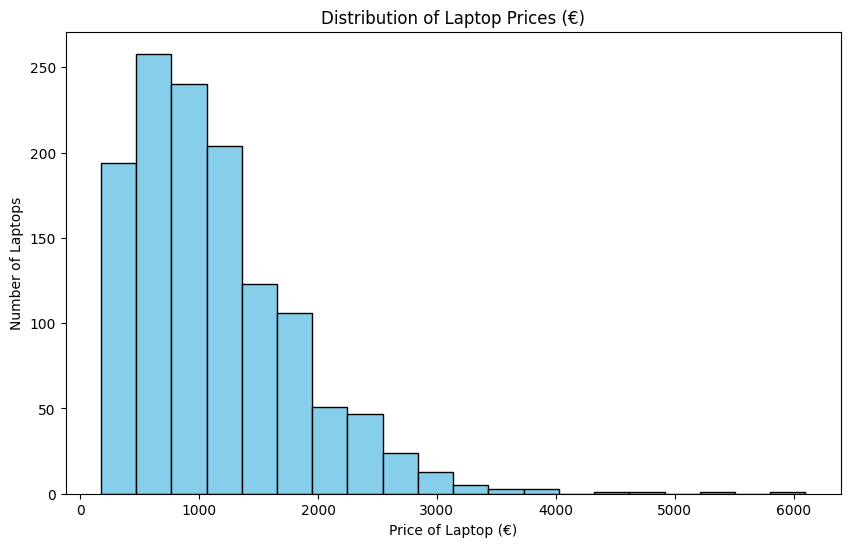

In [3]:
prices = laptop_prices_df['Price (Euro)']
plt.figure(figsize=(10, 6))
plt.hist(prices, bins = 20, color = 'skyblue', edgecolor = 'black')
plt.xlabel('Price of Laptop (€)')
plt.ylabel('Number of Laptops')
plt.title('Distribution of Laptop Prices (€)')
plt.show()

computing average laptop price per company

In [4]:
company_price_avg = laptop_prices_df.groupby('Company').agg({'Price (Euro)': 'mean'})
print("\n---Average Laptop Price per Company---")
company_price_avg


---Average Laptop Price per Company---


,Price (Euro)
Company,
Acer,633.464455
Apple,1564.198571
Asus,1123.829737
Chuwi,314.296667
Dell,1199.225120
Fujitsu,729.000000
Google,1677.666667
HP,1080.314664
Huawei,1424.000000


company with the most expensive laptop on average

In [5]:
company_avg_sorted = company_price_avg.sort_values(by = 'Price (Euro)', ascending =False)
print("The commpany with the most expensive laptops on average: ", company_avg_sorted.iloc[0])

The commpany with the most expensive laptops on average:  Price (Euro)    3346.142857
Name: Razer, dtype: float64


check for similar operating systems and unify them under consistent names

In [8]:
os_unique = laptop_prices_df["OpSys"].unique().copy()
print("Original OS types: ", os_unique)
os_mapping = {
    'Mac OS X': 'macOS', 
    'Windows 10 S': 'Windows 10'
}
laptop_prices_df["OpSys"].replace(os_mapping, inplace=True)
clean_os_unique = laptop_prices_df["OpSys"].unique()
print("Clean OS types: ", clean_os_unique)

Original OS types:  ['macOS' 'No OS' 'Windows 10' 'Mac OS X' 'Linux' 'Android' 'Windows 10 S'
 'Chrome OS' 'Windows 7']
Clean OS types:  ['macOS' 'No OS' 'Windows 10' 'Linux' 'Android' 'Chrome OS' 'Windows 7']
